# Prediction of Welding Quality



**Project overview**

This project builds a machine learning system that aims to predict welding quality metrics, using various welding parameters and chemical compositions.
It's a major concern for many industries worth several billion euros (e.g., wind turbine pipe welding). Today, weld quality knowledge is mainly transferred between experts, so making data accessible in order to capture and standardize expert knowledge represents a key industrial challenge.

## **Loading the Data**

The Data used in this notebook is accessible through this link : https://www.phase-trans.msm.cam.ac.uk/map/data/materials/welddb-b.html

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


In [ ]:
df = pd.read_csv('welddb.data', header=None, delim_whitespace=True)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1652, 44)


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,...,N,N,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,...,-28,100,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,...,-38,100,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0,N,N,N,N,...,N,N,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0,N,N,N,N,...,-48,100,N,N,32,28,40,0,0,Evans-Ni/CMn-1990/1991-0Bawch


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 44 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1652 non-null   float64
 1   1       1652 non-null   float64
 2   2       1652 non-null   float64
 3   3       1652 non-null   object 
 4   4       1652 non-null   object 
 5   5       1652 non-null   object 
 6   6       1652 non-null   object 
 7   7       1652 non-null   object 
 8   8       1652 non-null   object 
 9   9       1652 non-null   object 
 10  10      1652 non-null   object 
 11  11      1652 non-null   object 
 12  12      1652 non-null   object 
 13  13      1652 non-null   object 
 14  14      1652 non-null   object 
 15  15      1652 non-null   object 
 16  16      1652 non-null   object 
 17  17      1652 non-null   object 
 18  18      1652 non-null   object 
 19  19      1652 non-null   object 
 20  20      1652 non-null   object 
 21  21      1652 non-null   object 
 22  

**Assign proper column names**

We define the columns names such as described in the link of the dataset

In [ ]:
column_names = [
    "Carbon concentration (weight%)",
    "Silicon concentration (weight%)",
    "Manganese concentration (weight%)",
    "Sulphur concentration (weight%)",
    "Phosphorus concentration (weight%)",
    "Nickel concentration (weight%)",
    "Chromium concentration (weight%)",
    "Molybdenum concentration (weight%)",
    "Vanadium concentration (weight%)",
    "Copper concentration (weight%)",
    "Cobalt concentration (weight%)",
    "Tungsten concentration (weight%)",
    "Oxygen concentration (ppm by weight)",
    "Titanium concentration (ppm by weight)",
    "Nitrogen concentration (ppm by weight)",
    "Aluminium concentration (ppm by weight)",
    "Boron concentration (ppm by weight)",
    "Niobium concentration (ppm by weight)",
    "Tin concentration (ppm by weight)",
    "Arsenic concentration (ppm by weight)",
    "Antimony concentration (ppm by weight)",
    "Current (A)",
    "Voltage (V)",
    "AC or DC",
    "Electrode polarity (positive or negative)",
    "Heat input (kJmm-1)",
    "Interpass temperature (°C)",
    "Type of weld",
    "Post weld heat treatment temperature (°C)",
    "Post weld heat treatment time (hours)",
    "Yield strength (MPa)",
    "Ultimate tensile strength (MPa)",
    "Elongation (%)",
    "Reduction of Area (%)",
    "Charpy temperature (°C)",
    "Charpy impact toughness (J)",
    "Hardness (kgmm-2)",
    "50% FATT",
    "Primary ferrite in microstructure (%)",
    "Ferrite with second phase (%)",
    "Acicular ferrite (%)",
    "Martensite (%)",
    "Ferrite with carbide aggregate (%)",
    "Weld ID"
]

df.columns = column_names
print("Column names assigned successfully!")
df.head()

Column names assigned successfully!


,Carbon concentration (weight%),Silicon concentration (weight%),Manganese concentration (weight%),Sulphur concentration (weight%),Phosphorus concentration (weight%),Nickel concentration (weight%),Chromium concentration (weight%),Molybdenum concentration (weight%),Vanadium concentration (weight%),Copper concentration (weight%),...,Charpy temperature (°C),Charpy impact toughness (J),Hardness (kgmm-2),50% FATT,Primary ferrite in microstructure (%),Ferrite with second phase (%),Acicular ferrite (%),Martensite (%),Ferrite with carbide aggregate (%),Weld ID
0,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,...,N,N,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aaw
1,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,...,-28,100,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aawch
2,0.037,0.30,0.65,0.008,0.012,0,N,N,N,N,...,-38,100,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Aht
3,0.037,0.31,1.03,0.007,0.014,0,N,N,N,N,...,N,N,N,N,N,N,N,N,N,Evans-Ni/CMn-1990/1991-0Baw
4,0.037,0.31,1.03,0.007,0.014,0,N,N,N,N,...,-48,100,N,N,32,28,40,0,0,Evans-Ni/CMn-1990/1991-0Bawch


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1652 entries, 0 to 1651
Data columns (total 44 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Carbon concentration (weight%)             1652 non-null   float64
 1   Silicon concentration (weight%)            1652 non-null   float64
 2   Manganese concentration (weight%)          1652 non-null   float64
 3   Sulphur concentration (weight%)            1652 non-null   object 
 4   Phosphorus concentration (weight%)         1652 non-null   object 
 5   Nickel concentration (weight%)             1652 non-null   object 
 6   Chromium concentration (weight%)           1652 non-null   object 
 7   Molybdenum concentration (weight%)         1652 non-null   object 
 8   Vanadium concentration (weight%)           1652 non-null   object 
 9   Copper concentration (weight%)             1652 non-null   object 
 10  Cobalt concentration (we

## **Handle initial missing values**

Let's replace 'N' strings with the proper NaN values

In [ ]:
df.replace("N", np.nan, inplace=True)
print("Replaced 'N' with NaN")
print(f"Total missing values: {df.isnull().sum().sum()}")

Replaced 'N' with NaN
Total missing values: 33141


In [ ]:
print("Data types distribution:")
print(df.dtypes.value_counts())

Data types distribution:
object     40
float64     4
Name: count, dtype: int64


We have lots of features that have the object type. Let's try to convert them to numeric type

In [ ]:
def convert_to_numeric(column):
    try:
        return pd.to_numeric(column)
    except ValueError:
        return column

df = df.apply(convert_to_numeric)
print("After initial conversion:")
print(df.dtypes.value_counts())

After initial conversion:
float64    23
object     21
Name: count, dtype: int64


A number of these object columns remain let's inspect them individually

In [ ]:
# Identify all columns with object data type
obj_cols = [col for col in df.columns if df[col].dtype == 'object']

# Iterate over each selected column and print non-numeric entries
for col in obj_cols:
    print(f"Column '{col}' contains the following non-numeric values:")
    invalid_entries = df.loc[pd.to_numeric(df[col], errors='coerce').isna(), col].dropna().unique()
    print(invalid_entries[:10])  # Show first 10
    print()

Column 'Sulphur concentration (weight%)' contains the following non-numeric values:
['<0.002']

Column 'Molybdenum concentration (weight%)' contains the following non-numeric values:
['<0.01']

Column 'Vanadium concentration (weight%)' contains the following non-numeric values:
['<0.0005' '<0.01' '<0.005' '<5']

Column 'Copper concentration (weight%)' contains the following non-numeric values:
['<0.01']

Column 'Cobalt concentration (weight%)' contains the following non-numeric values:
['<0.01']

Column 'Tungsten concentration (weight%)' contains the following non-numeric values:
['<0.1']

Column 'Titanium concentration (ppm by weight)' contains the following non-numeric values:
['<5' '<100' '<0.01' '<10']

Column 'Nitrogen concentration (ppm by weight)' contains the following non-numeric values:
['67tot33res' '66totndres' '61tot34res' '54totndres' '54tot24res'
 '52tot18res' '50tot17res' '48tot18res']

Column 'Aluminium concentration (ppm by weight)' contains the following non-numeric 

## **Data Type Conversion and Cleaning**

### Analysis of Non-Numeric Values

From the inspection above, we can identify several types of non-numeric values:

1. **Inequality values**: Values like `<0.002`, `<0.01`, `<5`, `<100` indicate measurements below detection limits
2. **Categorical values**: `AC`, `DC`, `+`, `-`, and weld types like `MMA`, `ShMA`, etc.
3. **Range values**: Values like `150-200` indicating a range
4. **Complex strings**: Nitrogen concentration has values like `67tot33res` which appear to be composite measurements

Let's handle each category systematically.

### Step 1: Handle Inequality Values (Below Detection Limit)

**Decision**: For values like `<0.01`, we'll replace them with half of the detection limit (e.g., `<0.01` becomes `0.005`). This is a common approach in analytical chemistry when dealing with values below detection limits.

In [ ]:
import numpy as np
import pandas as pd
import hashlib
from scipy.stats import skewnorm

def _seed_from_cell(row_idx, col_name, extra="skewlod"):
    s = f"{row_idx}|{col_name}|{extra}"
    h = int(hashlib.sha256(s.encode()).hexdigest(), 16) % (2**32 - 1)
    return np.random.default_rng(h)


def sample_skew_truncated_near_x(
    x, low_ratio=0.6, alpha=6, n_draws=64, rng=None,
    tail_prob=0.25, tail_band=(0.25, 0.65)
):
    """
    Tirage skew-normal tronqué :
      - (1 - tail_prob) des cas dans [low_ratio*x, x)
      - tail_prob des cas dans [tail_band[0]*x, tail_band[1]*x]
    alpha > 0 => masse tirée vers le haut (proche de x)
    """
    if x is None or x <= 0:
        return 0.0


    if rng.random() < tail_prob:
        lo, hi = tail_band[0] * x, tail_band[1] * x
        a = max(2, alpha // 2)
        loc = (lo + hi) / 2.0
        scale = max((hi - lo) / 3.0, 1e-12)
    else:
        lo, hi = low_ratio * x, x
        a = alpha
        loc = x * 0.92
        scale = max((hi - lo) / 4.0, 1e-12)


    for _ in range(20): # Essayer jusqu'à 20 fois
        draws = skewnorm.rvs(a, loc=loc, scale=scale, size=n_draws, random_state=rng)
        keep = draws[(draws >= lo) & (draws < hi)]
        if keep.size:

            return keep[rng.integers(0, keep.size)]


        loc = (loc + hi) / 2.0
        scale *= 1.5


    return rng.uniform(lo, np.nextafter(hi, 0.0))


def impute_skew_near_threshold(
    df, cols, low_ratio=0.6, alpha=6, tail_prob=0.25, tail_band=(0.25, 0.65)
):
    """
    Remplace les valeurs '<x' dans les columns spécifiées par
    des tirages skew-normal tronqués proches du seuil x.
    Les valeurs originales sont remplacées directement, aucune colonne
    supplémentaire n'est ajoutée. Arrondit à 2 décimales.
    """
    out = df.copy()

    for col in cols:
        if col in out.columns:
            s_col = out[col].astype(str).str.strip()
            mask_inequality = s_col.str.startswith('<', na=False)

            if mask_inequality.sum() > 0:
                # Extract threshold values
                threshold_values = s_col[mask_inequality].str[1:].astype(float)

                # Apply sampling for each inequality value
                imputed_values = [
                    sample_skew_truncated_near_x(
                        x, low_ratio=low_ratio, alpha=alpha,
                        rng=_seed_from_cell(idx, col),
                        tail_prob=tail_prob, tail_band=tail_band
                    ) for idx, x in threshold_values.items()
                ]

                # Replace values in the dataframe
                out.loc[mask_inequality, col] = imputed_values

    return out


# Apply the imputation function to relevant columns
inequality_columns = [
    "Sulphur concentration (weight%)",
    "Molybdenum concentration (weight%)",
    "Vanadium concentration (weight%)",
    "Copper concentration (weight%)",
    "Cobalt concentration (weight%)",
    "Tungsten concentration (weight%)",
    "Titanium concentration (ppm by weight)",
    "Aluminium concentration (ppm by weight)",
    "Boron concentration (ppm by weight)",
    "Niobium concentration (ppm by weight)",
    "Tin concentration (ppm by weight)",
    "Arsenic concentration (ppm by weight)",
    "Antimony concentration (ppm by weight)"
]

# Use the new imputation function
df = impute_skew_near_threshold(df, inequality_columns)

# Ensure columns are numeric after imputation
for col in inequality_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')



### Step 2: Handle Nitrogen Concentration Special Values

**Analysis**: The nitrogen concentration column contains values like `67tot33res`, which appear to represent:
- Total nitrogen content (e.g., 67 ppm)
- Residual nitrogen content (e.g., 33 ppm)

**Decision**: We'll extract the total nitrogen value (first number) as it represents the complete nitrogen content.

In [ ]:
def parse_nitrogen(value):
    """
    Parse nitrogen concentration values.
    Format: 'XXtotYYres' -> extract XX (total nitrogen)
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, str) and 'tot' in value:
        try:
            # Extract the number before 'tot'
            total_value = value.split('tot')[0]
            return float(total_value)
        except:
            return np.nan
    return value

df["Nitrogen concentration (ppm by weight)"] = df["Nitrogen concentration (ppm by weight)"].apply(parse_nitrogen)
df["Nitrogen concentration (ppm by weight)"] = pd.to_numeric(df["Nitrogen concentration (ppm by weight)"], errors='coerce')


### Step 3: Handle Range Values (Interpass Temperature)

**Decision**: For range values like `150-200`, we'll use the midpoint of the range (e.g., `175`).

In [ ]:
def parse_range(value):
    """
    Parse range values (e.g., '150-200') and return the midpoint.
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, str) and '-' in value:
        try:
            parts = value.split('-')
            if len(parts) == 2:
                return (float(parts[0]) + float(parts[1])) / 2
        except:
            return np.nan
    return value

df["Interpass temperature (°C)"] = df["Interpass temperature (°C)"].apply(parse_range)
df["Interpass temperature (°C)"] = pd.to_numeric(df["Interpass temperature (°C)"], errors='coerce')


### Step 4: Handle Categorical Variables

**Categorical columns identified**:
- `AC or DC`: Binary categorical (AC/DC)
- `Electrode polarity (positive or negative)`: Binary categorical (+/-)
- `Type of weld`: Multi-class categorical (MMA, ShMA, FCA, SA, etc.)

**Decision**: We'll encode these appropriately:
- Binary categories: Label encoding (0/1)
- Multi-class: Keep as categorical for now (will be handled during modeling)

In [ ]:
# Encode AC or DC
print("Unique values in 'AC or DC':", df["AC or DC"].unique())
df["AC or DC"] = df["AC or DC"].map({'DC': 1, 'AC': 0})

# Encode Electrode polarity
print("Unique values in 'Electrode polarity':", df["Electrode polarity (positive or negative)"].unique())
df["Electrode polarity (positive or negative)"] = df["Electrode polarity (positive or negative)"].map({'+': 1, '-': 0})

# Type of weld - keep as categorical but check unique values
print("\nUnique weld types:")
print(df["Type of weld"].value_counts())



Unique values in 'AC or DC': ['DC' 'AC' nan]
Unique values in 'Electrode polarity': ['+' '0' '-' nan]

Unique weld types:
Type of weld
MMA      1140
SA        261
TSA        87
FCA        87
ShMA       40
NGSAW      18
NGGMA       7
SAA         4
GMAA        4
GTAA        4
Name: count, dtype: int64


### Step 5: Handle Hardness Column

In [ ]:
# Convert hardness to numeric
df["Hardness (kgmm-2)"] = pd.to_numeric(df["Hardness (kgmm-2)"], errors='coerce')

We decided to do no further treatment on this column since it has more than 92% missing value

### Step 6: Convert Remaining Numeric Columns

In [ ]:
# Define columns that are in ppm and need conversion to weight%
ppm_cols = [
    "Oxygen concentration (ppm by weight)",
    "Titanium concentration (ppm by weight)",
    "Nitrogen concentration (ppm by weight)",
    "Aluminium concentration (ppm by weight)",
    "Boron concentration (ppm by weight)",
    "Niobium concentration (ppm by weight)",
    "Tin concentration (ppm by weight)",
    "Arsenic concentration (ppm by weight)",
    "Antimony concentration (ppm by weight)"
]

# Convert ppm columns to weight%
print("Converting ppm concentrations to weight%...")
for col in ppm_cols:
    if col in df.columns:
        # Create a new column for the weight% value
        new_col_name = col.replace(" (ppm by weight)", " (weight%)")
        df[new_col_name] = df[col] / 1000
        print(f"  - Converted '{col}' to '{new_col_name}'")
        # Optionally, drop the original ppm column if no longer needed
        # df_cleaned = df_cleaned.drop(columns=[col])

print("\nConversion complete.")
print(f"New shape: {df.shape}")

Converting ppm concentrations to weight%...
  - Converted 'Oxygen concentration (ppm by weight)' to 'Oxygen concentration (weight%)'
  - Converted 'Titanium concentration (ppm by weight)' to 'Titanium concentration (weight%)'
  - Converted 'Nitrogen concentration (ppm by weight)' to 'Nitrogen concentration (weight%)'
  - Converted 'Aluminium concentration (ppm by weight)' to 'Aluminium concentration (weight%)'
  - Converted 'Boron concentration (ppm by weight)' to 'Boron concentration (weight%)'
  - Converted 'Niobium concentration (ppm by weight)' to 'Niobium concentration (weight%)'
  - Converted 'Tin concentration (ppm by weight)' to 'Tin concentration (weight%)'
  - Converted 'Arsenic concentration (ppm by weight)' to 'Arsenic concentration (weight%)'
  - Converted 'Antimony concentration (ppm by weight)' to 'Antimony concentration (weight%)'

Conversion complete.
New shape: (1652, 53)


In [ ]:
# List of columns that should be numeric (excluding categorical and ID)
numeric_columns = [col for col in df.columns if col not in ["Type of weld", "Weld ID"]]

# Convert to numeric
for col in numeric_columns:
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("✓ Final data type conversion completed.")
print(f"\nData types summary:")
print(df.dtypes.value_counts())

✓ Final data type conversion completed.

Data types summary:
float64    51
object      2
Name: count, dtype: int64


### Verify Data Types

In [ ]:
# Display columns that are still object type
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Columns still with object type: {object_cols}")

Columns still with object type: ['Type of weld', 'Weld ID']


## **Missing Data Analysis**

Now that we have cleaned the data types, let's perform a comprehensive analysis of missing values.

### Calculate Missing Value Statistics

In [ ]:
# Calculate missing value statistics
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
    'Data_Type': df.dtypes
})

missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)

print(f"Total columns with missing values: {len(missing_stats)}")
print(f"\nTop 20 columns with highest missing percentages:\n")
print(missing_stats.head(20).to_string())

Total columns with missing values: 46

Top 20 columns with highest missing percentages:

                                    Column  Missing_Count  Missing_Percentage Data_Type
0                                 50% FATT           1621           98.123487   float64
1         Tungsten concentration (weight%)           1577           95.460048   float64
2                        Hardness (kgmm-2)           1572           95.157385   float64
3                           Martensite (%)           1563           94.612591   float64
4       Ferrite with carbide aggregate (%)           1563           94.612591   float64
5            Ferrite with second phase (%)           1562           94.552058   float64
6                     Acicular ferrite (%)           1562           94.552058   float64
7    Primary ferrite in microstructure (%)           1556           94.188862   float64
8           Cobalt concentration (weight%)           1523           92.191283   float64
9    Arsenic concentration (ppm

### Visualize Missing Data Patterns

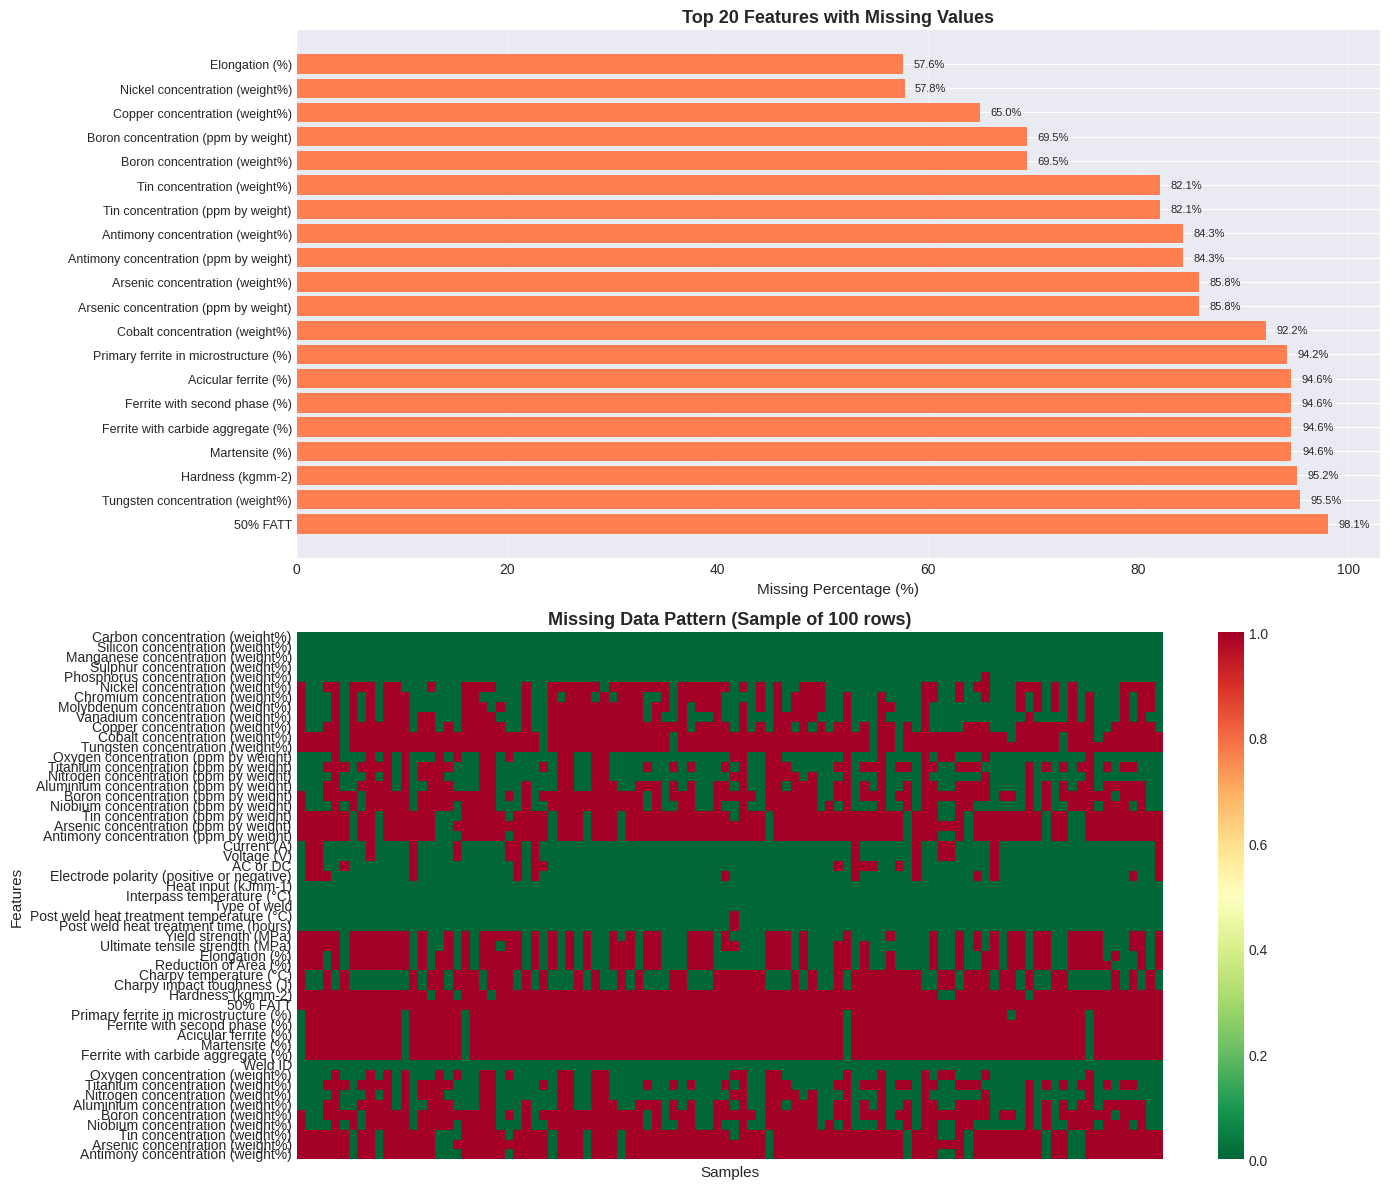


Overall missing data percentage: 47.65%


In [ ]:
# Create a comprehensive missing data visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Bar chart of missing percentages
top_missing = missing_stats.head(20)
axes[0].barh(range(len(top_missing)), top_missing['Missing_Percentage'], color='coral')
axes[0].set_yticks(range(len(top_missing)))
axes[0].set_yticklabels(top_missing['Column'], fontsize=9)
axes[0].set_xlabel('Missing Percentage (%)', fontsize=11)
axes[0].set_title('Top 20 Features with Missing Values', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add percentage labels
for i, v in enumerate(top_missing['Missing_Percentage']):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)

# Plot 2: Missing data heatmap (sample of rows)
sample_size = min(100, len(df))
sample_indices = np.random.choice(df.index, sample_size, replace=False)
missing_matrix = df.loc[sample_indices].isnull().T

sns.heatmap(missing_matrix, cmap='RdYlGn_r', cbar=True, ax=axes[1],
            yticklabels=True, xticklabels=False)
axes[1].set_title(f'Missing Data Pattern (Sample of {sample_size} rows)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Features', fontsize=11)
axes[1].set_xlabel('Samples', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nOverall missing data percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")

### Categorize Features by Missing Data Severity

**Strategy**:
- **Low missing** (<10%): Can use simple imputation
- **Medium missing** (10-40%): Require careful imputation strategy
- **High missing** (40-70%): Consider dropping or using indicator variables
- **Very high missing** (>70%): Strong candidates for removal

In [ ]:
# Categorize features by missing data severity
low_missing = missing_stats[missing_stats['Missing_Percentage'] < 10]['Column'].tolist()
medium_missing = missing_stats[(missing_stats['Missing_Percentage'] >= 10) &
                               (missing_stats['Missing_Percentage'] < 40)]['Column'].tolist()
high_missing = missing_stats[(missing_stats['Missing_Percentage'] >= 40) &
                             (missing_stats['Missing_Percentage'] < 70)]['Column'].tolist()
very_high_missing = missing_stats[missing_stats['Missing_Percentage'] >= 70]['Column'].tolist()

print(f"Low missing (<10%): {len(low_missing)} features")
print(low_missing)
print(f"\nMedium missing (10-40%): {len(medium_missing)} features")
print(medium_missing)
print(f"\nHigh missing (40-70%): {len(high_missing)} features")
print(high_missing)
print(f"\nVery high missing (>70%): {len(very_high_missing)} features")
print(very_high_missing)

Low missing (<10%): 4 features
['Post weld heat treatment time (hours)', 'Post weld heat treatment temperature (°C)', 'Phosphorus concentration (weight%)', 'Sulphur concentration (weight%)']

Medium missing (10-40%): 8 features
['Nitrogen concentration (weight%)', 'Nitrogen concentration (ppm by weight)', 'Oxygen concentration (ppm by weight)', 'Oxygen concentration (weight%)', 'Current (A)', 'Voltage (V)', 'AC or DC', 'Electrode polarity (positive or negative)']

High missing (40-70%): 19 features
['Boron concentration (weight%)', 'Boron concentration (ppm by weight)', 'Copper concentration (weight%)', 'Nickel concentration (weight%)', 'Elongation (%)', 'Reduction of Area (%)', 'Ultimate tensile strength (MPa)', 'Niobium concentration (weight%)', 'Niobium concentration (ppm by weight)', 'Yield strength (MPa)', 'Chromium concentration (weight%)', 'Molybdenum concentration (weight%)', 'Charpy impact toughness (J)', 'Charpy temperature (°C)', 'Aluminium concentration (ppm by weight)', 'A

## **Feature Analysis and Understanding**

Let's analyze the features by category to better understand the data.


### Define Feature Groups


In [ ]:
# Define feature groups for better organization
feature_groups = {
    'Chemical Composition (weight%)': [
        "Carbon concentration (weight%)",
        "Silicon concentration (weight%)",
        "Manganese concentration (weight%)",
        "Sulphur concentration (weight%)",
        "Phosphorus concentration (weight%)",
        "Nickel concentration (weight%)",
        "Chromium concentration (weight%)",
        "Molybdenum concentration (weight%)",
        "Vanadium concentration (weight%)",
        "Copper concentration (weight%)",
        "Cobalt concentration (weight%)",
        "Tungsten concentration (weight%)"
    ],
    'Chemical Composition (ppm)': [
        "Oxygen concentration (ppm by weight)",
        "Titanium concentration (ppm by weight)",
        "Nitrogen concentration (ppm by weight)",
        "Aluminium concentration (ppm by weight)",
        "Boron concentration (ppm by weight)",
        "Niobium concentration (ppm by weight)",
        "Tin concentration (ppm by weight)",
        "Arsenic concentration (ppm by weight)",
        "Antimony concentration (ppm by weight)"
    ],
    'Welding Process Parameters': [
        "Current (A)",
        "Voltage (V)",
        "AC or DC",
        "Electrode polarity (positive or negative)",
        "Heat input (kJmm-1)",
        "Interpass temperature (°C)",
        "Type of weld"
    ],
    'Post-Weld Treatment': [
        "Post weld heat treatment temperature (°C)",
        "Post weld heat treatment time (hours)"
    ],
    'Mechanical Properties (Target Variables)': [
        "Yield strength (MPa)",
        "Ultimate tensile strength (MPa)",
        "Elongation (%)",
        "Reduction of Area (%)",
        "Charpy temperature (°C)",
        "Charpy impact toughness (J)",
    ],
    'Microstructure': [
        "Primary ferrite in microstructure (%)",
        "Ferrite with second phase (%)",
        "Acicular ferrite (%)",
        "Martensite (%)",
        "Ferrite with carbide aggregate (%)"
    ]
}

# Print summary for each group
for group_name, features in feature_groups.items():
    print(f"\n{'='*60}")
    print(f"{group_name}")
    print(f"{'='*60}")
    for feature in features:
        if feature in df.columns:
            missing_pct = (df[feature].isnull().sum() / len(df)) * 100
            print(f"{feature:50s} - Missing: {missing_pct:5.1f}%")



Chemical Composition (weight%)
Carbon concentration (weight%)                     - Missing:   0.0%
Silicon concentration (weight%)                    - Missing:   0.0%
Manganese concentration (weight%)                  - Missing:   0.0%
Sulphur concentration (weight%)                    - Missing:   0.2%
Phosphorus concentration (weight%)                 - Missing:   0.6%
Nickel concentration (weight%)                     - Missing:  57.8%
Chromium concentration (weight%)                   - Missing:  52.5%
Molybdenum concentration (weight%)                 - Missing:  52.0%
Vanadium concentration (weight%)                   - Missing:  43.8%
Copper concentration (weight%)                     - Missing:  65.0%
Cobalt concentration (weight%)                     - Missing:  92.2%
Tungsten concentration (weight%)                   - Missing:  95.5%

Chemical Composition (ppm)
Oxygen concentration (ppm by weight)               - Missing:  24.0%
Titanium concentration (ppm by weight)     

### Statistical Summary of Numeric Features

In [ ]:
# Get summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
summary_stats = df[numeric_cols].describe().T
summary_stats['missing_%'] = (df[numeric_cols].isnull().sum() / len(df)) * 100
summary_stats = summary_stats.sort_values('missing_%', ascending=False)

print("Statistical Summary (sorted by missing percentage):")
print(summary_stats.head(20).to_string())

Statistical Summary (sorted by missing percentage):
                                        count        mean        std         min         25%         50%         75%       max  missing_%
50% FATT                                 31.0  -31.096774  43.644285 -126.000000  -62.000000  -15.000000    5.000000    30.000  98.123487
Tungsten concentration (weight%)         75.0    0.130828   0.455364    0.000000    0.000000    0.000000    0.000000     2.990  95.460048
Hardness (kgmm-2)                        80.0  215.700000  24.656321  154.000000  193.750000  221.000000  231.000000   265.000  95.157385
Ferrite with carbide aggregate (%)       89.0    0.438202   1.397685    0.000000    0.000000    0.000000    0.000000     8.000  94.612591
Martensite (%)                           89.0    0.337079   3.179994    0.000000    0.000000    0.000000    0.000000    30.000  94.612591
Acicular ferrite (%)                     90.0   52.833333  23.483798    0.000000   35.500000   60.000000   71.750000    

## **Missing Value Imputation Strategy**

Based on our analysis, we'll implement a comprehensive imputation strategy:

1. **Very high missing (>70%)**: Drop these features as they provide limited information
2. **High missing (40-70%)**: Create missing indicators + median imputation
3. **Medium missing (10-40%)**: Use median imputation
4. **Low missing (<10%)**: Use median/mode imputation

The **phosphorus** concentration andthe **sulphur** concentration contain very few missing values so we impute them using the mean value.
Ad for the other elements, we assume that a missing value corresponds to a concentration close to zero so we replace them by 0

In [ ]:
# Impute missing values for Phosphorus and Sulphur with the mean
p_mean = df["Phosphorus concentration (weight%)"].mean()
s_mean = df["Sulphur concentration (weight%)"].mean()

df["Phosphorus concentration (weight%)"].fillna(p_mean, inplace=True)
df["Sulphur concentration (weight%)"].fillna(s_mean, inplace=True)

print(f"Imputed missing values in Phosphorus concentration with the mean: {p_mean:.4f}")
print(f"Imputed missing values in Sulphur concentration with the mean: {s_mean:.4f}")

# Impute missing values for other specified elements with 0
elements_to_impute_zero = [
    "Nickel concentration (weight%)",
    "Chromium concentration (weight%)",
    "Molybdenum concentration (weight%)",
    "Vanadium concentration (weight%)",
    "Copper concentration (weight%)",
    "Oxygen concentration (ppm by weight)",
    "Titanium concentration (ppm by weight)",
    "Nitrogen concentration (ppm by weight)",
    "Aluminium concentration (ppm by weight)",
    "Boron concentration (ppm by weight)",
    "Niobium concentration (ppm by weight)",
    "Oxygen concentration (weight%)",
    "Titanium concentration (weight%)",
    "Nitrogen concentration (weight%)",
    "Aluminium concentration (weight%)",
    "Boron concentration (weight%)",
    "Niobium concentration (weight%)"
]

for col in elements_to_impute_zero:
    if col in df.columns:
        df[col].fillna(0, inplace=True)
        print(f"Imputed missing values in '{col}' with 0")

Imputed missing values in Phosphorus concentration with the mean: 0.0130
Imputed missing values in Sulphur concentration with the mean: 0.0095
Imputed missing values in 'Nickel concentration (weight%)' with 0
Imputed missing values in 'Chromium concentration (weight%)' with 0
Imputed missing values in 'Molybdenum concentration (weight%)' with 0
Imputed missing values in 'Vanadium concentration (weight%)' with 0
Imputed missing values in 'Copper concentration (weight%)' with 0
Imputed missing values in 'Oxygen concentration (ppm by weight)' with 0
Imputed missing values in 'Titanium concentration (ppm by weight)' with 0
Imputed missing values in 'Nitrogen concentration (ppm by weight)' with 0
Imputed missing values in 'Aluminium concentration (ppm by weight)' with 0
Imputed missing values in 'Boron concentration (ppm by weight)' with 0
Imputed missing values in 'Niobium concentration (ppm by weight)' with 0
Imputed missing values in 'Oxygen concentration (weight%)' with 0
Imputed missin

### Remove Features with Very High Missing Values

In [ ]:
# Identify features to drop (>70% missing)
threshold_drop = 70
cols_to_drop = missing_stats[missing_stats['Missing_Percentage'] > threshold_drop]['Column'].tolist()


print(f"Features to drop (>{threshold_drop}% missing):")
for col in cols_to_drop:
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f"  - {col}: {missing_pct:.1f}% missing")

# Create a copy before dropping
df_original = df.copy()

# Drop columns
df_cleaned = df.drop(columns=cols_to_drop)

print(f"\nShape before dropping: {df.shape}")
print(f"Shape after dropping: {df_cleaned.shape}")
print(f"Dropped {len(cols_to_drop)} features")

Features to drop (>70% missing):
  - 50% FATT: 98.1% missing
  - Tungsten concentration (weight%): 95.5% missing
  - Hardness (kgmm-2): 95.2% missing
  - Martensite (%): 94.6% missing
  - Ferrite with carbide aggregate (%): 94.6% missing
  - Ferrite with second phase (%): 94.6% missing
  - Acicular ferrite (%): 94.6% missing
  - Primary ferrite in microstructure (%): 94.2% missing
  - Cobalt concentration (weight%): 92.2% missing
  - Arsenic concentration (ppm by weight): 85.8% missing
  - Arsenic concentration (weight%): 85.8% missing
  - Antimony concentration (ppm by weight): 84.3% missing
  - Antimony concentration (weight%): 84.3% missing
  - Tin concentration (ppm by weight): 82.1% missing
  - Tin concentration (weight%): 82.1% missing

Shape before dropping: (1652, 53)
Shape after dropping: (1652, 38)
Dropped 15 features


## **Data Quality Validation**

Let's perform final checks to ensure data quality.

### Check for Remaining Issues

In [ ]:
print("=" * 60)
print("DATA QUALITY VALIDATION REPORT")
print("=" * 60)

# 1. Missing values
total_missing = df_cleaned.isnull().sum().sum()
print(f"\n1. Missing Values: {total_missing}")
if total_missing > 0:
    print("   Columns with missing values:")
    missing_cols = df_cleaned.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0]
    for col, count in missing_cols.items():
        print(f"   - {col}: {count}")

# 2. Duplicate rows
duplicates = df_cleaned.duplicated().sum()
print(f"\n2. Duplicate Rows: {duplicates}")

# 3. Infinite values
numeric_cols_final = df_cleaned.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df_cleaned[numeric_cols_final]).sum().sum()
print(f"\n3. Infinite Values: {inf_count}")

# 4. Data types
print(f"\n4. Data Types:")
print(df_cleaned.dtypes.value_counts())

# 5. Shape
print(f"\n5. Dataset Shape: {df_cleaned.shape}")
print(f"   - Rows: {df_cleaned.shape[0]}")
print(f"   - Columns: {df_cleaned.shape[1]}")

# 6. Memory usage
memory_mb = df_cleaned.memory_usage(deep=True).sum() / 1024 / 1024
print(f"\n6. Memory Usage: {memory_mb:.2f} MB")

print("\n" + "=" * 60)

DATA QUALITY VALIDATION REPORT

1. Missing Values: 6162
   Columns with missing values:
   - Current (A): 248
   - Voltage (V): 248
   - AC or DC: 215
   - Electrode polarity (positive or negative): 194
   - Post weld heat treatment temperature (°C): 13
   - Post weld heat treatment time (hours): 13
   - Yield strength (MPa): 872
   - Ultimate tensile strength (MPa): 914
   - Elongation (%): 952
   - Reduction of Area (%): 947
   - Charpy temperature (°C): 773
   - Charpy impact toughness (J): 773

2. Duplicate Rows: 0

3. Infinite Values: 0

4. Data Types:
float64    36
object      2
Name: count, dtype: int64

5. Dataset Shape: (1652, 38)
   - Rows: 1652
   - Columns: 38

6. Memory Usage: 0.65 MB



## **Export Cleaned Dataset**

Save the cleaned and preprocessed dataset for modeling.

In [ ]:
# Export to CSV
output_filename = 'welddb_cleaned.csv'
df_cleaned.to_csv(output_filename, index=False)
print(f"✓ Cleaned dataset saved to: {output_filename}")
print(f"  - Shape: {df_cleaned.shape}")
file_size = os.path.getsize(output_filename) / 1024 / 1024 if os.path.exists(output_filename) else 0
print(f"  - File size: {file_size:.2f} MB")

# Also save a version without engineered features (for comparison)
engineered_cols = ['Carbon_Equivalent', 'Total_Alloy_Content', 'Welding_Power',
                   'Heat_Treatment_Applied', 'Total_Microstructure_Pct',
                   'Carbon_Manganese_Interaction', 'Heat_Input_Per_Voltage']
base_cols = [col for col in df_cleaned.columns if col not in engineered_cols]
df_base = df_cleaned[base_cols]

output_base = 'welddb_cleaned_base.csv'
df_base.to_csv(output_base, index=False)
print(f"\n✓ Base dataset (without engineered features) saved to: {output_base}")
print(f"  - Shape: {df_base.shape}")

✓ Cleaned dataset saved to: welddb_cleaned.csv
  - Shape: (1652, 38)
  - File size: 0.34 MB

✓ Base dataset (without engineered features) saved to: welddb_cleaned_base.csv
  - Shape: (1652, 38)
